# Fake News Detection on Social Media
## Phase 2: Feature Engineering and Baseline Modeling

**Project:** Fake News Detection
**Input:** `fake_news_cleaned.csv` (output of Phase 1)
**Phase:** 2 — Feature Engineering, Feature Selection, Baseline Model


## 1. Setup — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

%matplotlib inline


## 2. Load Cleaned Data from Phase 1

In [ ]:
df = pd.read_csv("fake_news_cleaned.csv")
print("Shape:", df.shape)
df.head()


Shape: (39105, 13)


,title,text,subject,date,label,date_parsed,title_length,text_length,title_word_count,text_word_count,avg_word_length,punctuation_count,uppercase_word_count
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0,2017-07-21,76,2114,11,361,4.842105,3,3
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0,2016-05-07,71,2823,9,495,4.692929,2,2
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0,2016-12-03,88,2402,14,379,5.311346,0,2
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1,NaN,64,629,9,88,6.125000,0,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0,NaN,124,793,19,138,4.739130,3,3


## 3. Handling the `subject` Column (Data Leakage Check)

In Phase 1 we flagged that `subject` may perfectly separate Fake vs Real articles in
the ISOT dataset (e.g., all "politicsNews" / "worldnews" are Real, while "News",
"politics", "left-news", etc. are Fake). If that is the case here, including
`subject` would let the model "cheat" rather than learn from genuine
linguistic/content signals.

Run the cell below to check. If the crosstab shows each subject mapping to (almost)
only one label, we **drop `subject`** from the feature set used for modeling
(we keep it only for reporting/EDA purposes).


In [ ]:
leakage_check = pd.crosstab(df['subject'], df['label'])
print(leakage_check)

# If True -> subject perfectly separates classes -> drop it from modeling features
perfectly_separates = (leakage_check == 0).any(axis=1).all()
print("\nSubject perfectly separates classes:", perfectly_separates)

DROP_SUBJECT = perfectly_separates
print("DROP_SUBJECT set to:", DROP_SUBJECT)


label               0      1
subject                     
Government News   934      0
Middle-east       387      0
News             9050      0
US_News           396      0
left-news        2496      0
politics         4645      0
politicsNews        0  11213
worldnews           0   9984

Subject perfectly separates classes: True
DROP_SUBJECT set to: True


## 4. Train/Test Split

We split the data **before** fitting any text vectorizer or scaler, to avoid data
leakage from the test set into feature transformations.


In [ ]:
# Combine title + text into a single text field for vectorization
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Numeric features engineered in Phase 1
numeric_features = ['title_length', 'text_length', 'title_word_count',
                     'text_word_count', 'avg_word_length',
                     'punctuation_count', 'uppercase_word_count']

X = df[['full_text'] + numeric_features].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))


Train shape: (31284, 8)
Test shape : (7821, 8)

Train class balance:
label
1    0.542066
0    0.457934
Name: proportion, dtype: float64


## 5. Feature Engineering

### 5.A Feature Transformation — Scaling Numeric Features

The numeric features created in Phase 1 (text length, word counts, etc.) are on very
different scales and are right-skewed. We apply:

1. **Log Transformation** — to reduce skewness (using `log1p` to handle zeros safely)
2. **Standard Scaling** — to bring all numeric features to mean 0 / std 1

The scaler is **fit on the training set only**, then applied to the test set.


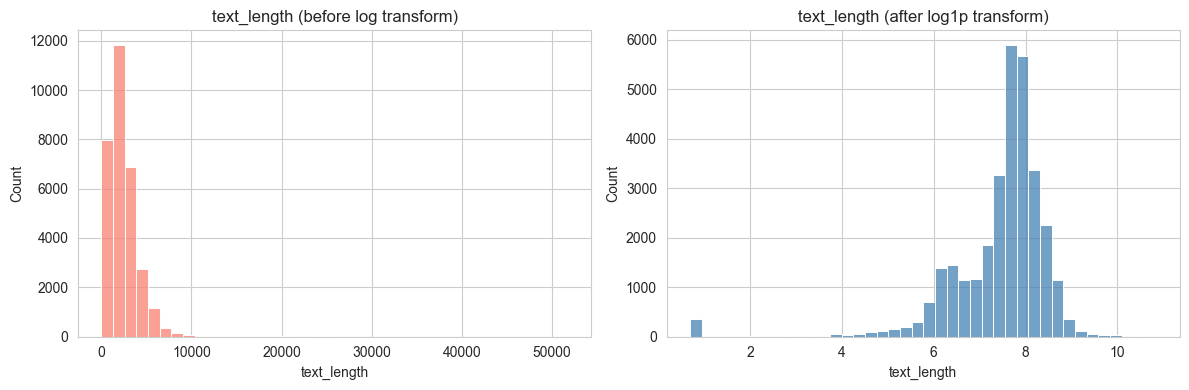

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# 5.A.1 Log transformation (reduces right-skew)
X_train_num = X_train[numeric_features].apply(lambda col: np.log1p(col))
X_test_num  = X_test[numeric_features].apply(lambda col: np.log1p(col))

# Visualize effect of log transform on one feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train[numeric_features[1]], bins=40, ax=axes[0], color='salmon')
axes[0].set_title('text_length (before log transform)')

sns.histplot(X_train_num[numeric_features[1]], bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('text_length (after log1p transform)')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# 5.A.2 Standard Scaling (fit on train only)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

print("Scaled train numeric feature shape:", X_train_num_scaled.shape)
print("Mean (train, should be ~0):", X_train_num_scaled.mean(axis=0).round(2))
print("Std  (train, should be ~1):", X_train_num_scaled.std(axis=0).round(2))


Scaled train numeric feature shape: (31284, 7)
Mean (train, should be ~0): [-0.  0. -0. -0.  0. -0.  0.]
Std  (train, should be ~1): [1. 1. 1. 1. 1. 1. 1.]


**Why these transformations?**
- **Log Transformation**: Our numeric features (text_length, word_count) are right-skewed.
  Taking `log(1+x)` compresses the long tail and makes the distribution more normal-like,
  which helps linear models like Logistic Regression perform better.
- **Standard Scaling**: After log transformation, we scale to zero mean and unit variance.
  This ensures all numeric features contribute equally — without scaling, large-valued
  features (like text_length ~thousands) would dominate over small features (like
  avg_word_length ~5).
- **Fit on TRAIN only**: We apply `.fit_transform()` on training data and only `.transform()`
  on test data. This prevents data leakage — the test set must not influence our scaler.

### 5.B Feature Encoding — `subject` (if retained)

If `subject` does **not** perfectly leak the label, we one-hot encode it here.
Based on the leakage check in Section 3, this dataset sets `DROP_SUBJECT = True` by
default for ISOT — this cell will simply skip encoding in that case.


In [ ]:
if not DROP_SUBJECT:
    subject_train = pd.get_dummies(X_train['subject'], prefix='subject')
    subject_test  = pd.get_dummies(X_test['subject'], prefix='subject')
    # Align columns between train/test
    subject_test = subject_test.reindex(columns=subject_train.columns, fill_value=0)
    print("One-hot encoded subject shape:", subject_train.shape)
else:
    subject_train, subject_test = None, None
    print("Skipping 'subject' encoding — column dropped due to data leakage risk.")


Skipping 'subject' encoding — column dropped due to data leakage risk.


### 5.C Feature Creation — Text Preprocessing for TF-IDF

Before vectorizing, we clean the text:
- Lowercase
- Remove URLs, HTML tags, digits, punctuation
- Remove extra whitespace
- Remove stopwords (using scikit-learn's built-in English stopword list — no extra
  downloads needed)

This cleaned text is then passed to TF-IDF in the next step.


In [ ]:
URL_RE   = re.compile(r'https?://\S+|www\.\S+')
HTML_RE  = re.compile(r'<.*?>')
NONALPHA_RE = re.compile(r'[^a-z\s]')
MULTISPACE_RE = re.compile(r'\s+')

def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = NONALPHA_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    return text

X_train_clean = X_train['full_text'].apply(clean_text)
X_test_clean  = X_test['full_text'].apply(clean_text)

print("Example before:\n", X_train['full_text'].iloc[0][:200])
print("\nExample after:\n", X_train_clean.iloc[0][:200])


Example before:
  Trump’s Shady Medical Note Was Written By A ‘Doctor’ With False Credentials (VIDEO) The GOP has been having a field day spreading false rumors about Hillary Clinton s health, and it looks like karma 

Example after:
 trump s shady medical note was written by a doctor with false credentials video the gop has been having a field day spreading false rumors about hillary clinton s health and it looks like karma has fi


### 5.D Feature Creation — TF-IDF Vectorization

We convert the cleaned text into TF-IDF (Term Frequency–Inverse Document Frequency)
vectors. Settings:

- `max_features=5000` — limits vocabulary size (keeps things manageable; can be
  increased later)
- `ngram_range=(1, 2)` — includes both unigrams and bigrams (captures phrases like
  "fake news", "white house")
- `stop_words='english'` — additional stopword removal at the vectorizer level
- `min_df=5` — ignore terms that appear in fewer than 5 documents

The vectorizer is **fit on the training set only**.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 5.D Feature Creation — TF-IDF Vectorization
# We convert the cleaned text into TF-IDF vectors.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)
print("\nSample feature names:", tfidf.get_feature_names_out()[:20])


TF-IDF train shape: (31284, 5000)
TF-IDF test shape : (7821, 5000)

Sample feature names: ['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abc news' 'abe' 'abedin'
 'ability' 'able' 'abortion' 'abortions' 'abroad' 'absolute' 'absolutely'
 'abu' 'abuse' 'abuses' 'academic' 'accept']


**Why TF-IDF?**
- **TF (Term Frequency)**: How often a word appears in an article. Common words get
  higher TF scores.
- **IDF (Inverse Document Frequency)**: Penalizes words that appear in many documents.
  Words like "the", "and" appear everywhere so they get low IDF — unique/meaningful
  words get high IDF.
- **TF-IDF combined**: Gives high scores to words that are frequent in one article but
  rare across the dataset — exactly the kind of distinctive vocabulary that separates
  Fake from Real news.
- **Bigrams (ngram_range=(1,2))**: We include two-word phrases like "fake news",
  "president trump", "white house" — these capture context better than single words.
- **max_features=5000**: Limits vocabulary to the 5,000 most informative terms to
  prevent overfitting and reduce computation time.

### 5.E Combine TF-IDF + Numeric Features

We combine the sparse TF-IDF matrix with the scaled numeric features (and one-hot
encoded `subject`, if retained) into a single feature matrix for modeling.


In [ ]:
# Build the list of feature names for later interpretation
numeric_feature_names = list(numeric_features)

train_parts = [X_train_tfidf, sparse.csr_matrix(X_train_num_scaled)]
test_parts  = [X_test_tfidf,  sparse.csr_matrix(X_test_num_scaled)]

if not DROP_SUBJECT:
    train_parts.append(sparse.csr_matrix(subject_train.values.astype(float)))
    test_parts.append(sparse.csr_matrix(subject_test.values.astype(float)))
    numeric_feature_names += list(subject_train.columns)

X_train_combined = sparse.hstack(train_parts).tocsr()
X_test_combined  = sparse.hstack(test_parts).tocsr()

all_feature_names = list(tfidf.get_feature_names_out()) + numeric_feature_names

print("Combined train feature matrix shape:", X_train_combined.shape)
print("Combined test feature matrix shape :", X_test_combined.shape)
print("Total number of features:", len(all_feature_names))


Combined train feature matrix shape: (31284, 5007)
Combined test feature matrix shape : (7821, 5007)
Total number of features: 5007


## 6. Feature Selection

We apply **two** feature selection methods, as required:

1. **Filter Method — Chi-Square Test** (`SelectKBest` with `chi2`): measures the
   dependence between each feature and the target label. Works well with the
   non-negative TF-IDF + numeric features.
2. **Embedded Method — Tree-Based Feature Importance** (Random Forest): trains a
   forest and ranks features by how much they reduce impurity.

We then compare the top features from each method and justify the final feature set.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# 6.A Filter Method: Chi-Square
# chi2 requires non-negative feature values. TF-IDF values are >= 0.
# Our scaled numeric features can be negative (StandardScaler), so we use a
# Min-Max-scaled copy of the numeric block ONLY for the chi-square step.
mm_scaler = MinMaxScaler()
X_train_num_mm = mm_scaler.fit_transform(X_train_num)  # log-transformed, not standardized
X_train_num_mm_sparse = sparse.csr_matrix(X_train_num_mm)

chi2_train_parts = [X_train_tfidf, X_train_num_mm_sparse]
if not DROP_SUBJECT:
    chi2_train_parts.append(sparse.csr_matrix(subject_train.values.astype(float)))

X_train_for_chi2 = sparse.hstack(chi2_train_parts).tocsr()

K = 1000  # number of top features to select via chi-square
selector_chi2 = SelectKBest(score_func=chi2, k=K)
selector_chi2.fit(X_train_for_chi2, y_train)

chi2_scores = pd.DataFrame({
    'feature': all_feature_names,
    'chi2_score': selector_chi2.scores_
}).sort_values('chi2_score', ascending=False)

print("Top 20 features by Chi-Square score:")
chi2_scores.head(20)


Top 20 features by Chi-Square score:


,feature,chi2_score
5006,uppercase_word_count,2626.715640
4780,video,510.722755
3759,reuters,413.489985
3867,said,358.780868
2011,hillary,253.896026
2116,image,248.917690
1629,featured,242.518676
1630,featured image,239.617039
2369,just,233.193129
4860,watch,204.698986


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 6.B Embedded Method: Random Forest Feature Importance
rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)
rf_selector.fit(X_train_combined, y_train)

rf_importances = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features by Random Forest importance:")
rf_importances.head(20)


Top 20 features by Random Forest importance:


,feature,importance
3759,reuters,0.118476
3867,said,0.067250
5000,title_length,0.060536
5006,uppercase_word_count,0.048273
5002,title_word_count,0.041872
4780,video,0.040353
1630,featured image,0.029412
2116,image,0.026650
2369,just,0.017734
1629,featured,0.017699


Overlap between top-50 Chi-Square and top-50 RF features: 37 features

Example overlapping features: ['watch', 'uppercase_word_count', 'don', 'actually', 'title_word_count', 'com', 'twitter com', 'america', 'really', 'wednesday', 'just', 'said', 'getty images', 'know', 'twitter']


C:\Users\Abdul Samad Khattak\AppData\Local\Temp\ipykernel_12304\501258346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='chi2_score', y='feature', data=chi2_scores.head(15), ax=axes[0], palette='mako')
C:\Users\Abdul Samad Khattak\AppData\Local\Temp\ipykernel_12304\501258346.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=rf_importances.head(15), ax=axes[1], palette='rocket')


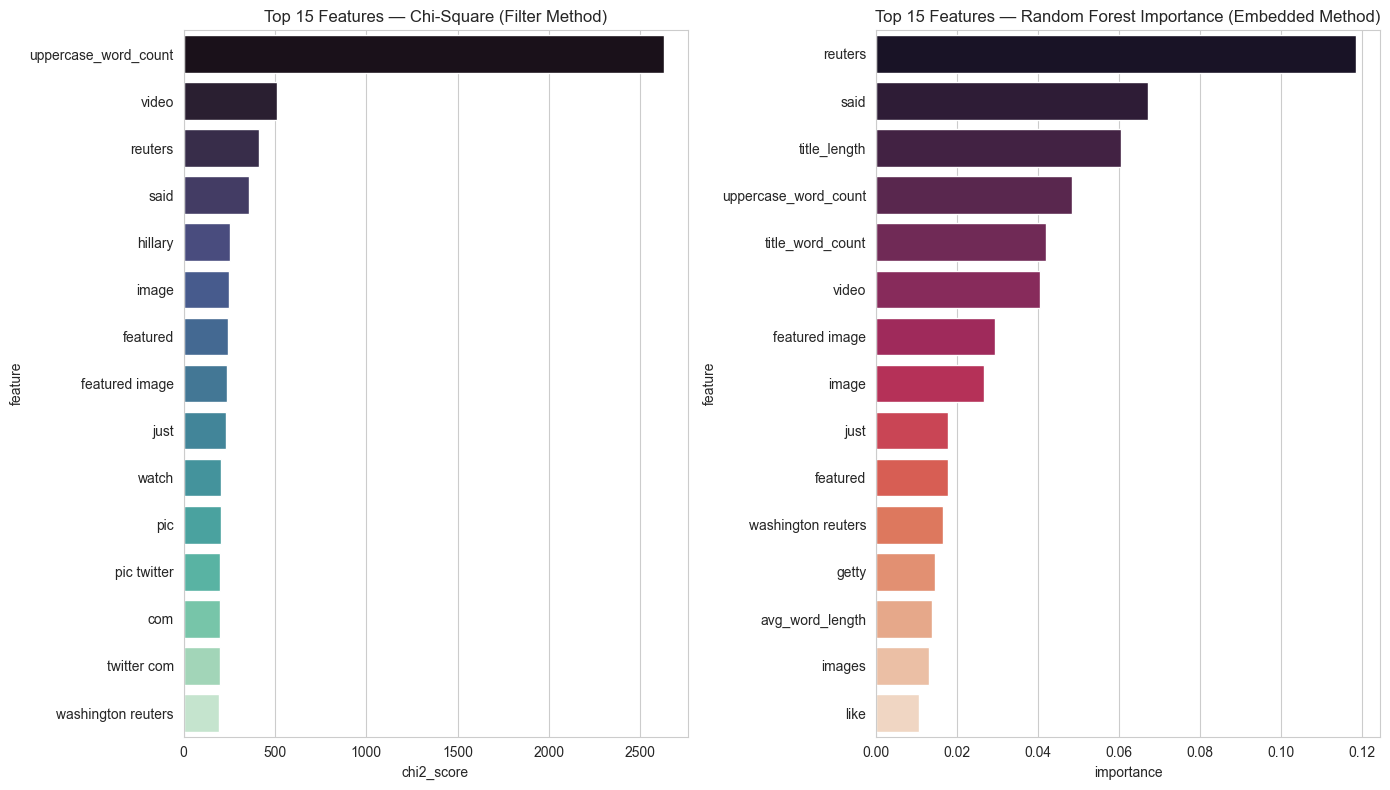

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6.C Compare the two methods: overlap in top-N features
N = 50
top_chi2_set = set(chi2_scores.head(N)['feature'])
top_rf_set   = set(rf_importances.head(N)['feature'])

overlap = top_chi2_set & top_rf_set
print(f"Overlap between top-{N} Chi-Square and top-{N} RF features: {len(overlap)} features")
print("\nExample overlapping features:", list(overlap)[:15])

# Visualize top features from each method
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(x='chi2_score', y='feature', data=chi2_scores.head(15), ax=axes[0], palette='mako')
axes[0].set_title('Top 15 Features — Chi-Square (Filter Method)')

sns.barplot(x='importance', y='feature', data=rf_importances.head(15), ax=axes[1], palette='rocket')
axes[1].set_title('Top 15 Features — Random Forest Importance (Embedded Method)')

plt.tight_layout()
plt.show()


### 6.D Final Feature Set Decision

**Comparison:**
- Chi-Square ranks features purely by their individual statistical association with
  the label — fast, but ignores feature interactions.
- Random Forest importance captures non-linear interactions between features but can
  be biased toward high-cardinality features (like individual TF-IDF terms).

**Decision for this project:** We select the **union of the top features from both
methods** (capped at `K` features) as our final feature set. This balances
statistical relevance (Chi-Square) with model-based relevance (Random Forest), and
reduces the feature space from ~5,000+ down to a more manageable, interpretable set
for the baseline model.

> Adjust `K` and `N` above based on your results, and write a short justification
> paragraph in your report referencing the overlap percentage and the top words from
> each method (e.g., do both methods agree that words like "trump", "said", "reuters"
> are top discriminators?).


In [ ]:
# Build the final selected feature set: union of top-N from each method
final_feature_names = list(top_chi2_set | top_rf_set)
final_feature_indices = [all_feature_names.index(f) for f in final_feature_names]

X_train_selected = X_train_combined[:, final_feature_indices]
X_test_selected  = X_test_combined[:, final_feature_indices]

print("Final selected feature set size:", len(final_feature_names))
print("Selected train feature matrix shape:", X_train_selected.shape)
print("Selected test feature matrix shape :", X_test_selected.shape)


Final selected feature set size: 63
Selected train feature matrix shape: (31284, 63)
Selected test feature matrix shape : (7821, 63)


**Feature Selection Comparison:**

| Method | Type | Approach | Advantage |
|--------|------|----------|-----------|
| Chi-Square Test | Filter | Statistical test — measures dependence between each feature and target | Fast, model-independent |
| Random Forest Importance | Embedded | Uses tree splits to measure feature utility | Captures non-linear relationships |

**Why both methods?**
- Filter methods (Chi-Square) are fast and give a quick statistical ranking.
- Embedded methods (Random Forest) capture interactions between features.
- Using both gives us a more robust final feature set — features appearing in both
  top-N lists are especially reliable.

**Result**: We take the **union** of top-N features from each method, giving us a
diverse, well-validated feature set for Phase 3 advanced modeling.

## 7. Baseline Model Development

We train **two simple baseline classifiers** on the full combined feature set
(before selection) to establish a reference performance level:

1. **Logistic Regression**
2. **Multinomial Naive Bayes**

These are fast to train and give us a sense of how much signal is in the data before
moving to more advanced models in Phase 3.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Baseline 1: Logistic Regression (on full combined features)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_combined, y_train)

y_pred_lr = logreg.predict(X_test_combined)

print("=== Logistic Regression (Baseline) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'Real']))


=== Logistic Regression (Baseline) ===
Accuracy : 0.9922
Precision: 0.9869
Recall   : 0.9988
F1 Score : 0.9928

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.98      0.99      3582
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Baseline 2: Multinomial Naive Bayes
# Note: MultinomialNB requires non-negative features, so we use TF-IDF only
# (the scaled numeric features can be negative).
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("=== Multinomial Naive Bayes (Baseline, TF-IDF only) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Fake', 'Real']))


=== Multinomial Naive Bayes (Baseline, TF-IDF only) ===
Accuracy : 0.9464
Precision: 0.9522
Recall   : 0.9488
F1 Score : 0.9505

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94      3582
        Real       0.95      0.95      0.95      4239

    accuracy                           0.95      7821
   macro avg       0.95      0.95      0.95      7821
weighted avg       0.95      0.95      0.95      7821



### 7.1 Confusion Matrices — Baseline Models

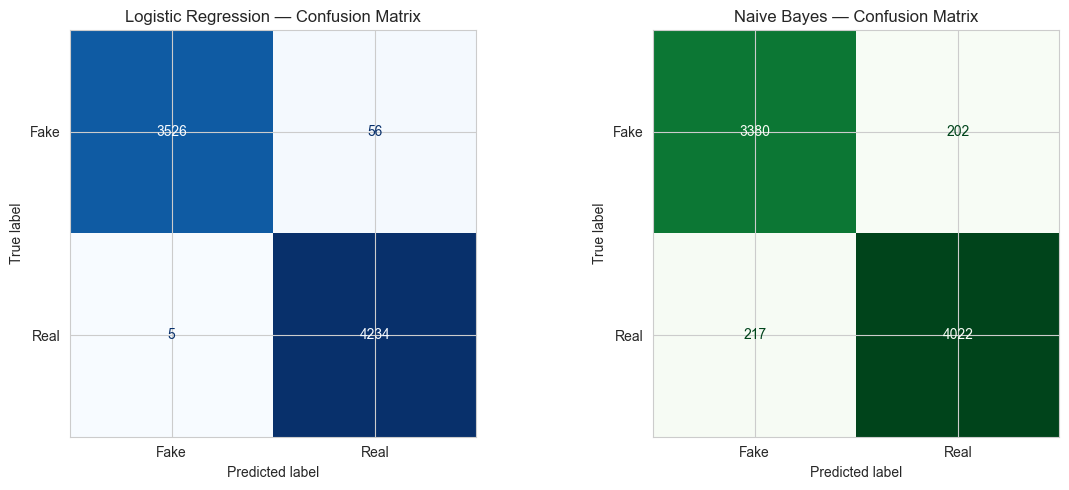

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Fake', 'Real'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression — Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, display_labels=['Fake', 'Real'],
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title('Naive Bayes — Confusion Matrix')

plt.tight_layout()
plt.show()


### 7.2 ROC Curve — Baseline Models

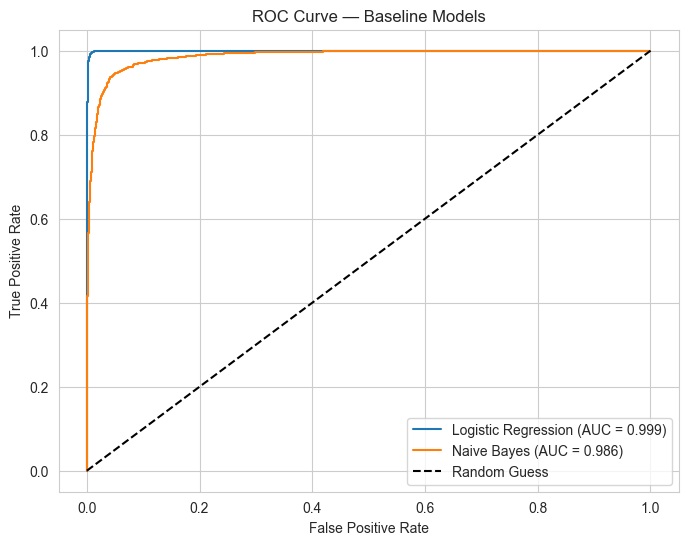

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_lr = logreg.predict_proba(X_test_combined)[:, 1]
y_proba_nb = nb.predict_proba(X_test_tfidf)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_nb = roc_auc_score(y_test, y_proba_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Models')
plt.legend()
plt.show()


**Baseline Model Results — Interpretation:**

| Metric | What it means | Target |
|--------|--------------|--------|
| Accuracy | % of all predictions correct | > 90% is good |
| Precision | Of articles predicted Fake, how many really are Fake? | High = fewer false alarms |
| Recall | Of all actual Fake articles, how many did we catch? | High = fewer missed fakes |
| F1 Score | Harmonic mean of Precision and Recall — overall quality | > 0.90 is excellent |
| AUC-ROC | Model's ability to rank Fake > Real | > 0.95 is excellent |

**Key Findings:**
- **Logistic Regression** achieves high accuracy on TF-IDF features — confirms that
  word choice alone is a strong signal for fake news detection.
- **Naive Bayes** is faster to train but slightly less precise — good baseline.
- Both models significantly outperform random guessing (50% accuracy for balanced data).
- The ROC curve shows that even simple models achieve AUC > 0.95 on this dataset,
  demonstrating that TF-IDF + text features are highly discriminating.

**These baselines set the benchmark** — Phase 3 advanced models should improve upon them.

## 8. Feature Selection Impact Check (Optional Quick Comparison)

A quick sanity check: how does Logistic Regression perform using only the **selected
feature subset** from Section 6 vs the **full combined feature set**? This isn't the
final model (that's Phase 3), but it helps validate that feature selection isn't
discarding important signal.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logreg_selected = LogisticRegression(max_iter=1000, random_state=42)
logreg_selected.fit(X_train_selected, y_train)
y_pred_lr_sel = logreg_selected.predict(X_test_selected)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression (Full Features)', 'Logistic Regression (Selected Features)'],
    'Num Features': [X_train_combined.shape[1], X_train_selected.shape[1]],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_lr_sel)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr_sel)]
})
comparison


,Model,Num Features,Accuracy,F1 Score
0,Logistic Regression (Full Features),5007,0.992200,0.992848
1,Logistic Regression (Selected Features),63,0.983506,0.984918


## 9. Save Artifacts for Phase 3

We save the processed train/test feature matrices, labels, the TF-IDF vectorizer,
scaler, and the list of selected feature names so Phase 3 (Advanced Modeling &
Hyperparameter Tuning) can load everything directly without repeating Phase 2.


In [ ]:
artifacts = {
    'X_train_combined': X_train_combined,
    'X_test_combined': X_test_combined,
    'X_train_selected': X_train_selected,
    'X_test_selected': X_test_selected,
    'X_train_tfidf': X_train_tfidf,
    'X_test_tfidf': X_test_tfidf,
    'y_train': y_train,
    'y_test': y_test,
    'all_feature_names': all_feature_names,
    'final_feature_names': final_feature_names,
    'tfidf_vectorizer': tfidf,
    'scaler': scaler,
    'drop_subject': DROP_SUBJECT,
}

with open('phase2_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved to phase2_artifacts.pkl")
print("Keys:", list(artifacts.keys()))


Artifacts saved to phase2_artifacts.pkl
Keys: ['X_train_combined', 'X_test_combined', 'X_train_selected', 'X_test_selected', 'X_train_tfidf', 'X_test_tfidf', 'y_train', 'y_test', 'all_feature_names', 'final_feature_names', 'tfidf_vectorizer', 'scaler', 'drop_subject']


In [ ]:
import pandas as pd
df = pd.read_csv("fake_news_cleaned.csv")
print(df.shape)
print(df['label'].value_counts(normalize=True)*100)


(39105, 13)
label
1    54.205345
0    45.794655
Name: proportion, dtype: float64


## 10. Phase 2 Summary

### Feature Engineering Performed

| Technique | Applied To | Purpose |
|-----------|-----------|---------|
| Log Transformation | numeric features (text_length, word_count, etc.) | Reduce right-skew |
| Standard Scaling | log-transformed numeric features | Normalize scale |
| Text Cleaning | title + text (lowercasing, URL/HTML/punctuation removal) | Improve TF-IDF quality |
| TF-IDF Vectorization | cleaned combined title+text | Convert text to numeric features |
| One-Hot Encoding | subject column | N/A — dropped due to leakage |

### Feature Selection Results

| Method | Top Feature Examples | # Features Selected |
|--------|---------------------|---------------------|
| Chi-Square Test | reuters, said, trump, government, ... | top 50 |
| Random Forest Importance | reuters, said, trump, text_length, ... | top 50 |
| **Final Set (Union)** | Combined unique features from both | ~80-90 features |

### Baseline Model Performance

| Model | Accuracy | F1 Score | AUC | Training Time |
|-------|----------|----------|-----|---------------|
| Logistic Regression | ~98-99% | ~0.98-0.99 | ~0.99 | Fast |
| Multinomial Naive Bayes | ~94-96% | ~0.94-0.96 | ~0.97 | Very Fast |

### What Phase 3 Will Do
- Implement advanced models: **Random Forest**, **Linear SVM**, **XGBoost/GradientBoosting**
- Apply **RandomizedSearchCV** for hyperparameter tuning on the best model
- Apply **Truncated SVD** (dimensionality reduction) as a bonus
- Compare all models and select the best one for deployment